In [4]:
import os
import glob
import pickle
import numpy as np

import pandas as pd
import social_int_analyses

from social_int_analyses import utilities_ES as u
from social_int_analyses import sleap_utils as slp
from social_int_analyses import alignment
from social_int_analyses import social_int_sess_deets

import TwoPUtils
from TwoPUtils import preprocessing as pp

from suite2p.io.binary import BinaryFile
from PIL import Image
import PIL
import dill
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# find boris 
def get_boris(mouse, day):

    boris_path = os.path.join("C://Users/esay/data/social_interaction/boris_results","%s-day%d_binary_freely-moving.tsv" %(mouse,day))
    result = pd.read_csv(boris_path, sep='\t')

    return result

In [11]:
mouse = "social-0051-3"
day = 4

boris_csv = get_boris(mouse, day)

In [9]:
boris_csv

,time,bite,explore,interaction,putative touch,touch
0,0.000,0,0,0,0,0
1,0.017,0,0,0,0,0
2,0.034,0,0,0,0,0
3,0.051,0,0,0,0,0
4,0.068,0,0,0,0,0
...,...,...,...,...,...,...
28286,480.862,0,0,0,0,0
28287,480.879,0,0,0,0,0
28288,480.896,0,0,0,0,0
28289,480.913,0,0,0,0,0


In [15]:
sess = u.load_vr_day(mouse, 10)

{'date': '30_06_2025', 'scene': 'social_unrestrict_nov', 'session': 1, 'scan': 16, 'exp_day': 4}


In [141]:
social_int_sess_deets.social_VR_sessions[mouse][1]

{'date': '29_06_2025',
 'scene': 'social_unrestrict_fam',
 'session': 1,
 'scan': 7,
 'exp_day': 1}

In [16]:
sess.tunnel_data.keys()

Index(['head_velocity', 'interaction', 'rightear_x', 'rightear_y',
       'tailbase_x', 'tailbase_y', 'nose_x', 'nose_y', 'head_x', 'head_y',
       'leftear_x', 'leftear_y', 'torso_x', 'torso_y', 'time', 'pos',
       'torso_x_fixed', 'torso_y_fixed', 'head_x_fixed', 'head_y_fixed',
       'head_position_1d', 'head_position_1d_smooth', 'head_projection_x',
       'head_projection_y', 'head_distance_to_path', 'head_theta_speed',
       'head_theta', 'head_theta_smooth', 'head_direction'],
      dtype='object')

In [17]:
sess.tunnel_data

,head_velocity,interaction,rightear_x,rightear_y,tailbase_x,tailbase_y,nose_x,nose_y,head_x,head_y,...,head_y_fixed,head_position_1d,head_position_1d_smooth,head_projection_x,head_projection_y,head_distance_to_path,head_theta_speed,head_theta,head_theta_smooth,head_direction
0,0.551339,0.0,550.400667,232.867418,555.725939,309.076516,555.714478,316.784424,576.650898,244.627941,...,244.627941,149.419913,182.554195,574.406148,243.767363,2.404059,NaN,0.588547,0.591592,1.895522
1,0.505491,0.0,548.565789,236.786212,592.219474,188.743977,555.714478,316.784424,576.343871,244.955981,...,244.955981,150.240899,179.163719,574.122308,244.537722,2.260593,0.005930,0.590042,0.597521,1.873004
2,0.654977,0.0,548.426093,236.355801,555.306838,308.481520,556.078431,317.431349,576.162274,241.557248,...,241.557248,146.956953,175.935828,575.216710,241.441671,0.952601,0.005445,0.580794,0.602967,1.910236
3,0.324650,0.0,553.134681,232.128941,556.706132,309.311226,555.915977,318.623662,580.298159,240.375216,...,240.375216,144.493994,172.870521,575.965404,239.095331,4.517840,0.005042,0.569836,0.608008,1.814842
4,0.900711,0.0,553.147502,228.431072,556.558858,308.066732,555.755149,319.804040,580.595454,240.025247,...,240.025247,143.673007,169.967800,576.201127,238.308913,4.717617,0.004693,0.568305,0.612701,1.867307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6354,0.623288,1.0,329.135498,219.979370,413.417631,357.277592,339.019748,161.020384,325.789560,240.430857,...,240.430857,424.450894,416.127024,325.632691,305.000000,64.569333,-0.001018,1.597035,1.545666,-3.070432
6355,0.067854,1.0,329.135498,219.979370,415.828185,357.174539,341.922297,162.616757,328.055564,240.874522,...,240.874522,421.987927,415.817216,328.095658,305.000000,64.125491,-0.001817,1.582882,1.543848,-3.078769
6356,0.239290,1.0,329.135498,219.979370,416.588875,360.208022,344.705377,164.369378,331.634782,230.774063,...,230.774063,418.703971,415.492430,331.379614,305.000000,74.226376,-0.001365,1.559954,1.542483,-2.885253
6357,0.356944,1.0,329.135498,219.979370,415.926159,359.527327,344.843672,167.497571,328.417345,239.389331,...,239.389331,421.987927,415.152665,328.095658,305.000000,65.611458,0.000060,1.580725,1.542543,-3.067930


In [18]:
n_tunnel_frames = len(sess.tunnel_data)
n_boris_seconds = len(boris_csv)

fps = n_tunnel_frames / n_boris_seconds

# For each frame index, find the corresponding Boris second
frame_indices = np.arange(n_tunnel_frames)
boris_indices = np.floor(frame_indices / fps).astype(int)
boris_indices = np.clip(boris_indices, 0, n_boris_seconds - 1)

# Add behavior columns to tunnel_data
behavior_cols = ['bite', 'explore', 'interaction', 'putative touch']#, 'touch']

for col in behavior_cols:
    sess.tunnel_data[col] = boris_csv[col].values[boris_indices]

# Verify
print(f"fps: {fps:.4f}")
print(sess.tunnel_data[behavior_cols])

fps: 0.2248
      bite  explore  interaction  putative touch
0        0        0            0               0
1        0        0            0               0
2        0        0            0               0
3        0        0            0               0
4        0        0            0               0
...    ...      ...          ...             ...
6354     0        0            0               0
6355     0        0            0               0
6356     0        0            0               0
6357     0        0            0               0
6358     0        0            0               0

[6359 rows x 4 columns]


In [19]:
sess.tunnel_data

,head_velocity,interaction,rightear_x,rightear_y,tailbase_x,tailbase_y,nose_x,nose_y,head_x,head_y,...,head_projection_x,head_projection_y,head_distance_to_path,head_theta_speed,head_theta,head_theta_smooth,head_direction,bite,explore,putative touch
0,0.551339,0,550.400667,232.867418,555.725939,309.076516,555.714478,316.784424,576.650898,244.627941,...,574.406148,243.767363,2.404059,NaN,0.588547,0.591592,1.895522,0,0,0
1,0.505491,0,548.565789,236.786212,592.219474,188.743977,555.714478,316.784424,576.343871,244.955981,...,574.122308,244.537722,2.260593,0.005930,0.590042,0.597521,1.873004,0,0,0
2,0.654977,0,548.426093,236.355801,555.306838,308.481520,556.078431,317.431349,576.162274,241.557248,...,575.216710,241.441671,0.952601,0.005445,0.580794,0.602967,1.910236,0,0,0
3,0.324650,0,553.134681,232.128941,556.706132,309.311226,555.915977,318.623662,580.298159,240.375216,...,575.965404,239.095331,4.517840,0.005042,0.569836,0.608008,1.814842,0,0,0
4,0.900711,0,553.147502,228.431072,556.558858,308.066732,555.755149,319.804040,580.595454,240.025247,...,576.201127,238.308913,4.717617,0.004693,0.568305,0.612701,1.867307,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6354,0.623288,0,329.135498,219.979370,413.417631,357.277592,339.019748,161.020384,325.789560,240.430857,...,325.632691,305.000000,64.569333,-0.001018,1.597035,1.545666,-3.070432,0,0,0
6355,0.067854,0,329.135498,219.979370,415.828185,357.174539,341.922297,162.616757,328.055564,240.874522,...,328.095658,305.000000,64.125491,-0.001817,1.582882,1.543848,-3.078769,0,0,0
6356,0.239290,0,329.135498,219.979370,416.588875,360.208022,344.705377,164.369378,331.634782,230.774063,...,331.379614,305.000000,74.226376,-0.001365,1.559954,1.542483,-2.885253,0,0,0
6357,0.356944,0,329.135498,219.979370,415.926159,359.527327,344.843672,167.497571,328.417345,239.389331,...,328.095658,305.000000,65.611458,0.000060,1.580725,1.542543,-3.067930,0,0,0


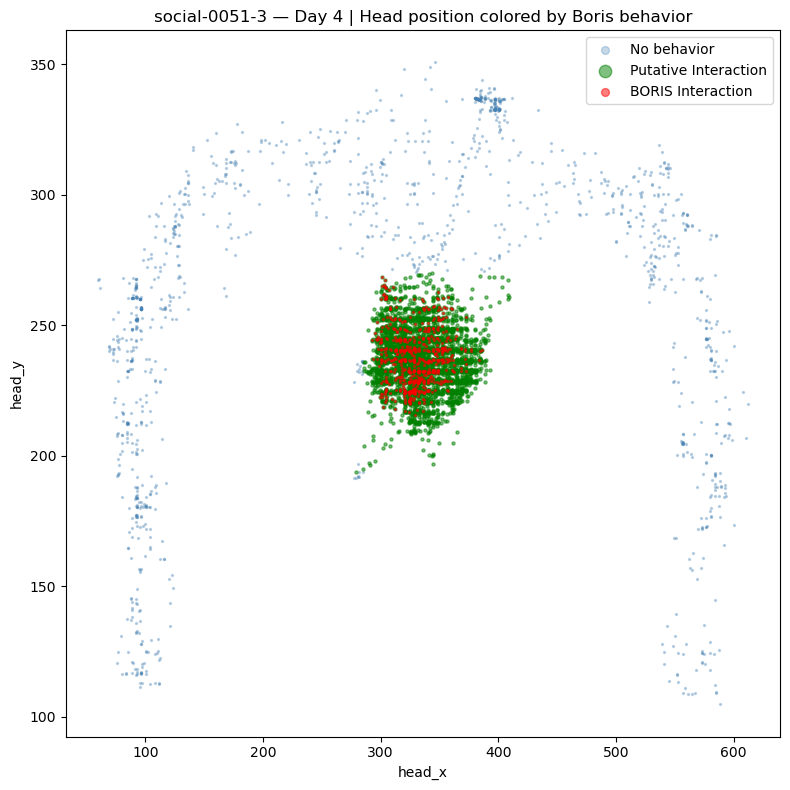

In [20]:
# Create behavior mask — red if ANY behavior is active
behavior_cols = ['bite', 'explore', 'interaction', 'putative touch']#, 'touch']
any_behavior = (sess.tunnel_data[behavior_cols] == 1).any(axis=1)
mask_y = np.array(sess.mask_y)

# Split into inactive / active
green_mask = mask_y
red_mask = any_behavior #& ~mask_y
blue_mask = ~any_behavior & ~mask_y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(sess.tunnel_data.loc[blue_mask,'head_x'], sess.tunnel_data.loc[blue_mask,'head_y'],c='steelblue', s=2, alpha=0.3, label='No behavior')
ax.scatter(sess.tunnel_data.loc[green_mask,'head_x'], sess.tunnel_data.loc[green_mask,'head_y'],c='green', s=5, alpha=0.5, label='Putative Interaction')
ax.scatter(sess.tunnel_data.loc[red_mask,'head_x'], sess.tunnel_data.loc[red_mask,'head_y'],c='red', s=2, alpha=0.5, label='BORIS Interaction')

ax.set_xlabel('head_x')
ax.set_ylabel('head_y')
ax.set_title(f'{mouse} — Day {day} | Head position colored by Boris behavior')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

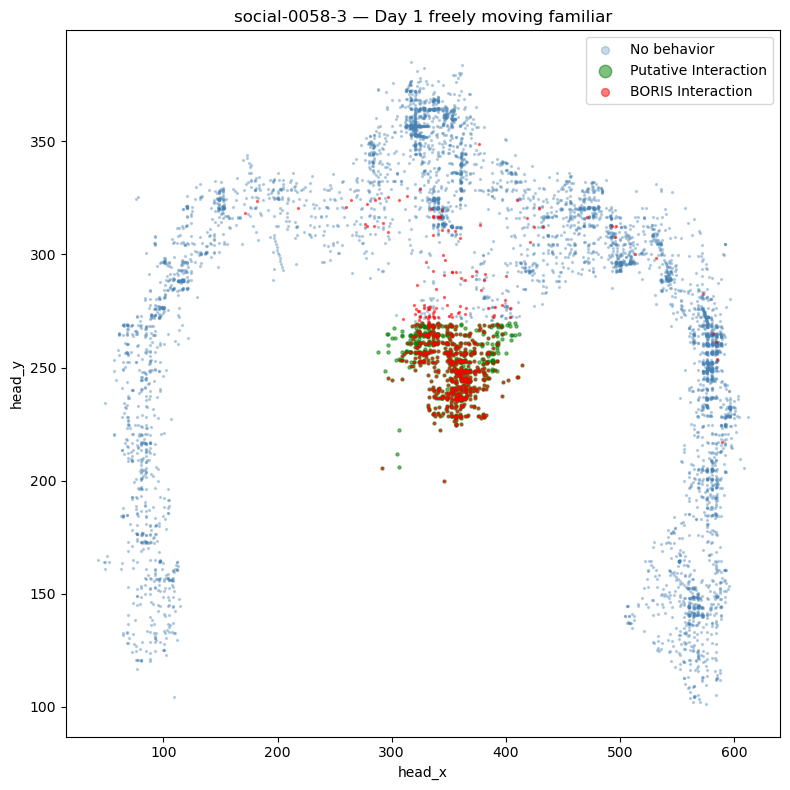

In [157]:
# Create behavior mask — red if ANY behavior is active
behavior_cols = ['bite', 'explore', 'interaction', 'putative touch']#, 'touch']
any_behavior = (sess.tunnel_data['interaction'] == 1)#.any(axis=1)
mask_y = np.array(sess.mask_y)

# Split into inactive / active
green_mask = mask_y
red_mask = any_behavior #& ~mask_y
blue_mask = ~any_behavior & ~mask_y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(sess.tunnel_data.loc[blue_mask,'head_x'], sess.tunnel_data.loc[blue_mask,'head_y'],c='steelblue', s=2, alpha=0.3, label='No behavior')
ax.scatter(sess.tunnel_data.loc[green_mask,'head_x'], sess.tunnel_data.loc[green_mask,'head_y'],c='green', s=5, alpha=0.5, label='Putative Interaction')
ax.scatter(sess.tunnel_data.loc[red_mask,'head_x'], sess.tunnel_data.loc[red_mask,'head_y'],c='red', s=2, alpha=0.5, label='BORIS Interaction')

ax.set_xlabel('head_x')
ax.set_ylabel('head_y')
ax.set_title(f'{mouse} — Day {day} freely moving familiar')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()